# <font color=' palegreen'>Data Science CA</font>

<font color='palegreen'>Aidin Kazemi: 810101561</font>

<font color='palegreen'>Ali Zilouchi: 810101560</font>

<font color='palegreen'>Paria Pasehvarz: 810101393</font>

##<font color='orange'>**Task 2 - Semantic Search on NiniSite**</font>

### <font color='skyblue'>1. Preprocessing</font>

####1. Dataset Loading

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import json
import pandas as pd

with open('/content/drive/MyDrive/DataScience/CAs/CA56/Task2/PerCQA_JSON_Format.json', 'r', encoding='utf-8-sig') as f:
    data = json.load(f)

df = pd.json_normalize(
    data,
    record_path='Comments',
    meta=['QID', 'QDATE', 'QUSERID', 'QTYPE', 'QGOLD_YN', 'QUsername', 'QBody', 'QSubject'],
    errors='ignore'
)

In [3]:
df.head()

,CID,CUSERID,CGOLD,CGOLD_YN,CSubject,CBody,CBodyClean,CUsername,CDate,LabelDate,ReplayCommentId,QID,QDATE,QUSERID,QTYPE,QGOLD_YN,QUsername,QBody,QSubject
0,50758322,4918,Good,,,قهر جدا تولد جدا. ضمنا خواهرانه میگم این قهر و...,قهر جدا تولد جدا. ضمنا خواهرانه میگم این قهر و...,mahboub,None,2020-04-28T23:57:28.9458377,NaN,1550088,2018-01-01T12:14:00,9101,General,Not Applicable,sami1366,دوستان نامزدم (شوهرم)باهام قهره امروز تولدشه چ...,قهر شوهرم
1,50758362,4939,Good,,,انقدر تحويلش نگير تا خودش بياد سمتت،اين جوري ا...,انقدر تحویلش نگیر تا خودش بیاد سمتت ، این جوری...,eshghiii,None,2020-04-29T00:32:46.1344058,NaN,1550088,2018-01-01T12:14:00,9101,General,Not Applicable,sami1366,دوستان نامزدم (شوهرم)باهام قهره امروز تولدشه چ...,قهر شوهرم
2,50758382,9102,Good,,,تولد براش بگير. قهر جداس,تولد براش بگیر. قهر جداس,44,None,2020-04-29T00:32:48.054768,NaN,1550088,2018-01-01T12:14:00,9101,General,Not Applicable,sami1366,دوستان نامزدم (شوهرم)باهام قهره امروز تولدشه چ...,قهر شوهرم
3,50758410,9103,Good,,,تولدشون رو تبریک بگین . جوری که احساس نکنن دار...,تولدشون رو تبریک بگین. جوری که احساس نکنن داری...,golsa82,None,2020-04-29T00:43:34.305984,NaN,1550088,2018-01-01T12:14:00,9101,General,Not Applicable,sami1366,دوستان نامزدم (شوهرم)باهام قهره امروز تولدشه چ...,قهر شوهرم
4,50758416,8643,Good,,,تو کادوت رو بخر و آماده بزار تا شب اگه زنگت نز...,تو کادوت رو بخر و آماده بزار تا شب اگه زنگت نز...,بهاران_عشق,None,2020-04-29T00:43:41.4450752,NaN,1550088,2018-01-01T12:14:00,9101,General,Not Applicable,sami1366,دوستان نامزدم (شوهرم)باهام قهره امروز تولدشه چ...,قهر شوهرم


####2. Normalize Persian and Arabic characters

We used Parsivar for preprocessing task. Parsivar itself:
*  Replace Arabic chars
* Remove diacritics (harakats)
* Standardize spacing
* Fix punctuation spacing
* Replace half-spaces

However, tasks such as removing unusual symbols (e.g., emojis, Latin characters) and normalizing numbers or repeated characters need to be implemented by me

#####1. Import necessary libraries

In [4]:
!pip install parsivar

In [5]:
import pandas as pd
import re
from parsivar import Normalizer

#####2. Initialize Parsivar Normalizer

we set **statistical_space_correction=False**, because we are preprocessing informal Persian text.

In [6]:
parsivar_normalizer = Normalizer(statistical_space_correction=False)

#####3. Define the cleaning function using Parsivar

In [7]:
def custom_clean_parsivar(text):
    if not isinstance(text, str):
        return text

    # Step 1: Normalize using Parsivar (handles Arabic chars, spacing, half-spaces)
    text = parsivar_normalizer.normalize(text)

    # Step 2: Remove unwanted symbols
    text = re.sub(r'<[^>]+>', ' ', text)                         # remove HTML tags
    text = re.sub(r'[a-zA-Z]', '', text)                         # remove Latin characters
    text = re.sub(r'[^\u0600-\u06FF\u200c\s.,!?؟،]', ' ', text)  # keep Persian chars, punctuation, ZWNJ
    text = re.sub(r'\.{2,}', '.', text)                          # normalize repeated dots
    text = re.sub(r'\s+', ' ', text)                             # normalize whitespace
    text = text.strip()

    return text

#####4. Apply cleaning function to CBody column

In [8]:
df['CBody_clean'] = df['CBody'].apply(custom_clean_parsivar)

#####5. Preview cleaned output

In [9]:
print(df[['CBody', 'CBody_clean']].head())

                                               CBody  \
0  قهر جدا تولد جدا. ضمنا خواهرانه میگم این قهر و...   
1  انقدر تحويلش نگير تا خودش بياد سمتت،اين جوري ا...   
2                           تولد براش بگير. قهر جداس   
3  تولدشون رو تبریک بگین . جوری که احساس نکنن دار...   
4  تو کادوت رو بخر و آماده بزار تا شب اگه زنگت نز...   

                                         CBody_clean  
0  قهر جدا تولد جدا . ضمنا خواهرانه میگم این قهر ...  
1  انقدر تحویلش نگیر تا خودش بیاد سمتت ، این جوری...  
2                          تولد براش بگیر . قهر جداس  
3  تولدشون رو تبریک بگین . جوری که احساس نکنن دار...  
4  تو کادوت رو بخر و آماده بزار تا شب اگه زنگت نز...  


####3. Remove diacritics and unwanted characters

#####1. Import necessary libraries

In [10]:
import re

#####2. Compile regex pattern for Arabic diacritics

In [11]:
arabic_diacritics = re.compile(r'[\u064B-\u0652]')

#####3. Define function that removes diacritics from a Series

In [12]:
def remove_diacritics_series(series):
    return series.apply(lambda x: arabic_diacritics.sub('', x) if isinstance(x, str) else x)

#####4. Apply to the already-cleaned column

In [13]:
df['CBody_nodiacritics'] = remove_diacritics_series(df['CBody_clean'])

#####5. Preview changes

In [14]:
print(df[['CBody_clean', 'CBody_nodiacritics']].head())

                                         CBody_clean  \
0  قهر جدا تولد جدا . ضمنا خواهرانه میگم این قهر ...   
1  انقدر تحویلش نگیر تا خودش بیاد سمتت ، این جوری...   
2                          تولد براش بگیر . قهر جداس   
3  تولدشون رو تبریک بگین . جوری که احساس نکنن دار...   
4  تو کادوت رو بخر و آماده بزار تا شب اگه زنگت نز...   

                                  CBody_nodiacritics  
0  قهر جدا تولد جدا . ضمنا خواهرانه میگم این قهر ...  
1  انقدر تحویلش نگیر تا خودش بیاد سمتت ، این جوری...  
2                          تولد براش بگیر . قهر جداس  
3  تولدشون رو تبریک بگین . جوری که احساس نکنن دار...  
4  تو کادوت رو بخر و آماده بزار تا شب اگه زنگت نز...  


####4. Tokenization

We used Parsivar for tokenization

#####1. Import necessary libraries

In [15]:
from parsivar import Tokenizer

#####2. Initialize Parsivar tokenizer

In [16]:
parsivar_tokenizer = Tokenizer()

#####3. Apply to cleaned column

In [17]:
df['CBody_tokens'] = df['CBody_nodiacritics'].apply(lambda x: parsivar_tokenizer.tokenize_words(x) if isinstance(x, str) else [])

#####4. View tokenized examples

In [18]:
print(df[['CBody_nodiacritics', 'CBody_tokens']].head())

                                  CBody_nodiacritics  \
0  قهر جدا تولد جدا . ضمنا خواهرانه میگم این قهر ...   
1  انقدر تحویلش نگیر تا خودش بیاد سمتت ، این جوری...   
2                          تولد براش بگیر . قهر جداس   
3  تولدشون رو تبریک بگین . جوری که احساس نکنن دار...   
4  تو کادوت رو بخر و آماده بزار تا شب اگه زنگت نز...   

                                        CBody_tokens  
0  [قهر, جدا, تولد, جدا, ., ضمنا, خواهرانه, میگم,...  
1  [انقدر, تحویلش, نگیر, تا, خودش, بیاد, سمتت, ،,...  
2                   [تولد, براش, بگیر, ., قهر, جداس]  
3  [تولدشون, رو, تبریک, بگین, ., جوری, که, احساس,...  
4  [تو, کادوت, رو, بخر, و, آماده, بزار, تا, شب, ا...  


####5. Plot unigram, bigram, and trigram frequencies

#####1. Import libraries

In [19]:
!pip install arabic_reshaper

In [20]:
!pip install python-bidi

In [21]:
from collections import Counter
from nltk.util import ngrams
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import arabic_reshaper
from bidi.algorithm import get_display

#####2. Define n-gram frequency function

In [22]:
def plot_ngrams(tokens_list, n=1, top_k=20, title=''):
    all_ngrams = []
    for tokens in tokens_list:
        ngram_list = list(ngrams(tokens, n))
        all_ngrams.extend(ngram_list)

    counter = Counter(all_ngrams)
    most_common = counter.most_common(top_k)

    ngram_phrases = [get_display(arabic_reshaper.reshape(' '.join(ng))) for ng, _ in most_common]

    counts = [cnt for _, cnt in most_common]

    plt.figure(figsize=(12, 6))
    sns.barplot(x=counts, y=ngram_phrases)
    plt.title(title)
    plt.xlabel("Frequency")
    plt.ylabel(f"{n}-grams")
    plt.show()

#####3. Prepare token lists

In [23]:
# Tokens before stopword removal
tokens_original = df['CBody_tokens'].dropna().tolist()

#####4. Plot n-grams before stopword removal

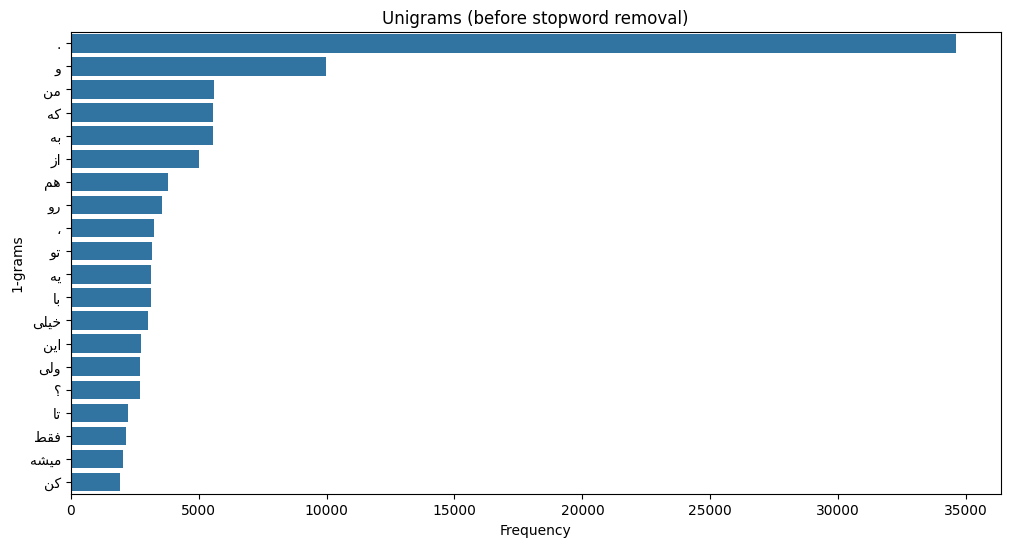

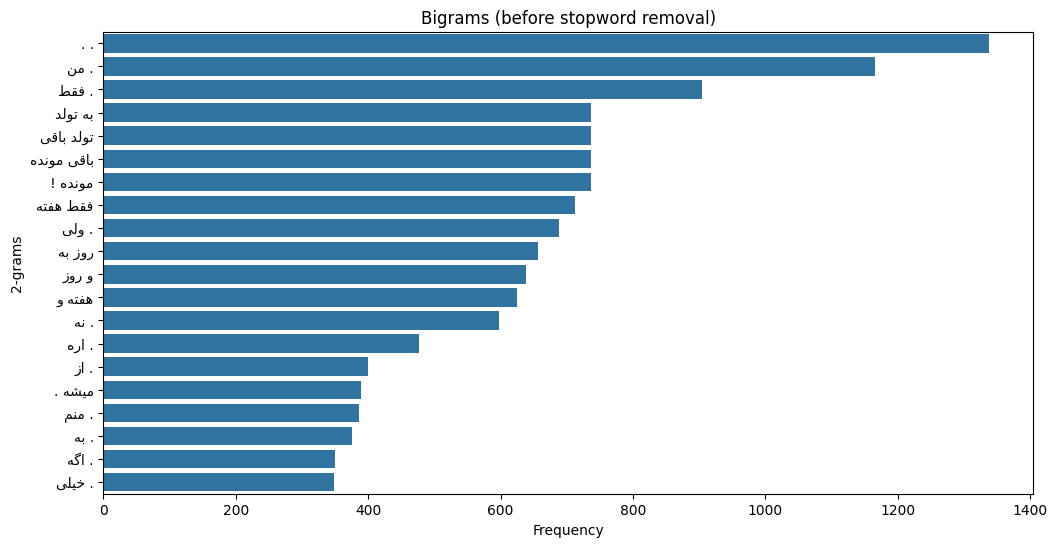

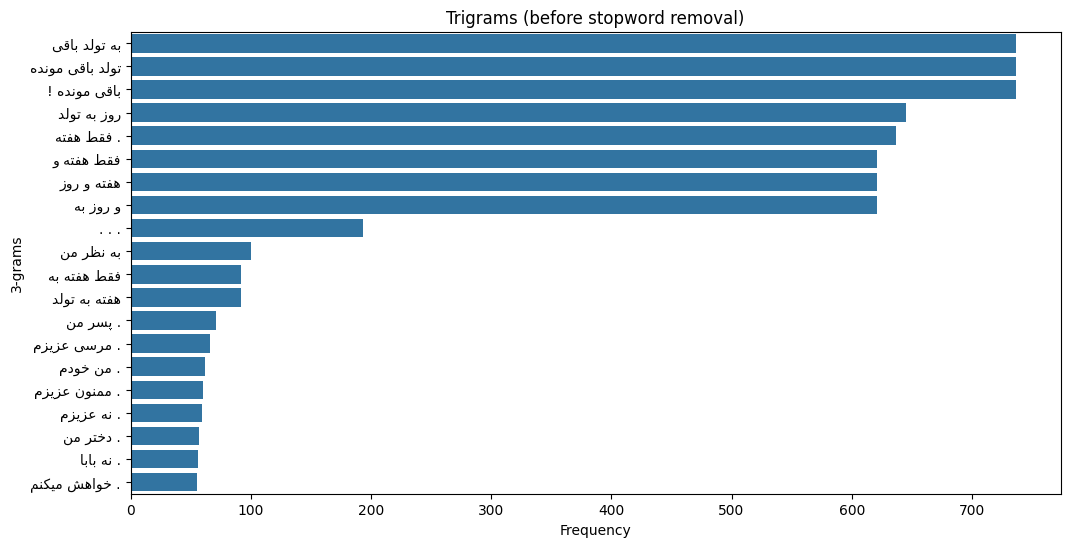

In [24]:
plot_ngrams(tokens_original, n=1, title="Unigrams (before stopword removal)")
plot_ngrams(tokens_original, n=2, title="Bigrams (before stopword removal)")
plot_ngrams(tokens_original, n=3, title="Trigrams (before stopword removal)")

####6. Remove stopwords

We used Hazm for this step (Parsivar does no cover it)

#####1. Import necessary libraries

In [25]:
!pip install hazm --no-deps

In [26]:
!pip install python-crfsuite

In [27]:
from hazm import stopwords_list

#####2. Load Persian stopwords


In [28]:
stopwords = set(stopwords_list())

#####3. Function to remove stopwords from list of tokens


In [29]:
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stopwords]

#####4. Apply to your DataFrame

In [30]:
df['CBody_tokens_nostop'] = df['CBody_tokens'].apply(remove_stopwords)

#####5. View removed stopwords example

In [31]:
print(df[['CBody_tokens', 'CBody_tokens_nostop']].head())

                                        CBody_tokens  \
0  [قهر, جدا, تولد, جدا, ., ضمنا, خواهرانه, میگم,...   
1  [انقدر, تحویلش, نگیر, تا, خودش, بیاد, سمتت, ،,...   
2                   [تولد, براش, بگیر, ., قهر, جداس]   
3  [تولدشون, رو, تبریک, بگین, ., جوری, که, احساس,...   
4  [تو, کادوت, رو, بخر, و, آماده, بزار, تا, شب, ا...   

                                 CBody_tokens_nostop  
0  [قهر, جدا, تولد, جدا, ., ضمنا, خواهرانه, میگم,...  
1  [انقدر, تحویلش, نگیر, بیاد, سمتت, ،, جوری, ادب...  
2                   [تولد, براش, بگیر, ., قهر, جداس]  
3  [تولدشون, تبریک, بگین, ., جوری, احساس, نکنن, د...  
4  [کادوت, بخر, آماده, بزار, شب, اگه, زنگت, نزد, ...  


####7. Stemming and Lemmatization

I will use leemmantizer in this step to have more accuracy

#####1. Import necessary libraries

In [32]:
from hazm import Lemmatizer

#####2. Initialize tools

In [33]:
lemmatizer = Lemmatizer()

#####3. Apply to Tokenized Text

In [34]:
df['tokens_lemmatized'] = df['CBody_tokens_nostop'].apply(
    lambda tokens: [lemmatizer.lemmatize(t).split('#')[0] for t in tokens]
)

#####4. View Results

In [35]:
print(df[['CBody_tokens_nostop', 'tokens_lemmatized']].head())


                                 CBody_tokens_nostop  \
0  [قهر, جدا, تولد, جدا, ., ضمنا, خواهرانه, میگم,...   
1  [انقدر, تحویلش, نگیر, بیاد, سمتت, ،, جوری, ادب...   
2                   [تولد, براش, بگیر, ., قهر, جداس]   
3  [تولدشون, تبریک, بگین, ., جوری, احساس, نکنن, د...   
4  [کادوت, بخر, آماده, بزار, شب, اگه, زنگت, نزد, ...   

                                   tokens_lemmatized  
0  [قهر, جدا, تولد, جدا, ., ضمنا, خواهرانه, میگ, ...  
1  [انقدر, تحویل, نگیر, بیاد, سمت, ،, جوری, ادب, ...  
2                   [تولد, براش, بگیر, ., قهر, جداس]  
3  [تولدشون, تبریک, بگین, ., جوری, احساس, نکنن, د...  
4  [کادو, بخر, آماده, بزار, شب, اگه, زنگت, نزد, ....  


####8. Normalize informal stretching and repetition

#####1. Import necessary libraries

In [36]:
from hazm import Normalizer

#####2. Initialize tools

In [37]:
hazm_normalizer = Normalizer()

#####3. Apply to lemmantized text

In [38]:
df['CBody_norepeat'] = df['tokens_lemmatized'].apply(
    lambda x: hazm_normalizer.normalize(x) if isinstance(x, str) else x
)

#####4. View Results

In [39]:
print(df[['tokens_lemmatized', 'CBody_norepeat']].head())

                                   tokens_lemmatized  \
0  [قهر, جدا, تولد, جدا, ., ضمنا, خواهرانه, میگ, ...   
1  [انقدر, تحویل, نگیر, بیاد, سمت, ،, جوری, ادب, ...   
2                   [تولد, براش, بگیر, ., قهر, جداس]   
3  [تولدشون, تبریک, بگین, ., جوری, احساس, نکنن, د...   
4  [کادو, بخر, آماده, بزار, شب, اگه, زنگت, نزد, ....   

                                      CBody_norepeat  
0  [قهر, جدا, تولد, جدا, ., ضمنا, خواهرانه, میگ, ...  
1  [انقدر, تحویل, نگیر, بیاد, سمت, ،, جوری, ادب, ...  
2                   [تولد, براش, بگیر, ., قهر, جداس]  
3  [تولدشون, تبریک, بگین, ., جوری, احساس, نکنن, د...  
4  [کادو, بخر, آماده, بزار, شب, اگه, زنگت, نزد, ....  


####9. Replace informal or slang expressions

Hazm or Parsivar does not have a slang dictionary, so I had to implement it:

#####1. Define slang dictionary

In [40]:
slang_dict = {
    # Emotion / surprise
    "عه": "تعجب",
    "عهه": "تعجب",
    "وای": "تعجب",
    "ووی": "تعجب",
    "اوو": "تعجب",
    "هی": "صداکردن",

    # Laughter / joking
    "خخخ": "خنده",
    "ههه": "خنده",

    # Pain / frustration
    "آخ": "درد",
    "اوخ": "درد",
    "اووف": "ناراحتی",
    "اوف": "ناراحتی",
    "آآخ": "درد",

    # Approval / excitement
    "جووون": "خوشایند",
    "جون": "خوشایند",
    "باحال": "خوشایند",
    "عاالی": "عالی",
    "عالیی": "عالی",
    "مرسیی": "مرسی",
    "دمت گرم": "تشکر",
    "دمت": "تشکر",

    # Negation / rejection
    "نا": "نه",
    "نن": "نه",
    "نهه": "نه",
    "نچ": "نه",
    "هرگز": "نه",
    "نی": "نه",

    # Agreement
    "آره": "بله",
    "اره": "بله",
    "اوکی": "باشه",
    "باشهه": "باشه",
    "حتما": "قبول",

    # Fillers and chat terms
    "اصن": "اصلا",
    "ینی": "یعنی",
    "الکی": "بیخودی",
    "نمیدونم": "نمی‌دانم",
    "نمیدونستی": "نمی‌دانستی",
    "نگو": "نگو",
    "نگفتی": "نمی‌گفتی"
}

#####2. Define function to replace slang words

In [41]:
def normalize_and_replace(token, slang_map):
    token = re.sub(r'(.)\1{2,}', r'\1', token)  # normalize repetition
    return slang_map.get(token, token)

#####3. Apply to normalized text

In [42]:
df['tokens_final'] = df['CBody_norepeat'].apply(
    lambda tokens: [normalize_and_replace(t, slang_dict) for t in tokens]
)

#####4. Show results

In [43]:
print(df[['CBody_norepeat', 'tokens_final']].head())

                                      CBody_norepeat  \
0  [قهر, جدا, تولد, جدا, ., ضمنا, خواهرانه, میگ, ...   
1  [انقدر, تحویل, نگیر, بیاد, سمت, ،, جوری, ادب, ...   
2                   [تولد, براش, بگیر, ., قهر, جداس]   
3  [تولدشون, تبریک, بگین, ., جوری, احساس, نکنن, د...   
4  [کادو, بخر, آماده, بزار, شب, اگه, زنگت, نزد, ....   

                                        tokens_final  
0  [قهر, جدا, تولد, جدا, ., ضمنا, خواهرانه, میگ, ...  
1  [انقدر, تحویل, نگیر, بیاد, سمت, ،, جوری, ادب, ...  
2                   [تولد, براش, بگیر, ., قهر, جداس]  
3  [تولدشون, تبریک, بگین, ., جوری, احساس, نکنن, د...  
4  [کادو, بخر, آماده, بزار, شب, اگه, زنگت, نزد, ....  


####10. Displaying Persian Text Correctly

sentences show up properly without arabic reshaper

### <font color='skyblue'>2. EDA</font>

####1. Understand the structure of questions and answers

#####1. Group rows by question (QBody)

In [44]:
grouped = df.groupby('QBody')

#####2. Display 2 sample questions and their answers

In [45]:
for i, (question, group) in enumerate(grouped):
    if i >= 2:
        break
    print(f"\n--- Question {i+1} ---")
    print("Original Question:", question)

    print("Answers:")
    for ans in group['CBody']:
        print("-", ans)

    print("\nCleaned (tokenized) answers:")
    for tokens in group['tokens_final']:
        print("-", tokens)




--- Question 1 ---
Original Question:   ژل كليندامايسن چقدر بايد روی پوست بمونه؟
Answers:
- تا موقعی که خشک بشه&nbsp;
- واسه چی هست حالا 🤔🤔🤔🤔
- واسه جوشه؟
- . جوش&nbsp;. من بعد از اصلاح ميزنم
- . اره
- از دسته این جوشا من دارم دیونه میشم
- . خوبه؟واسه هرنوع پوستی پیشه استفاده کرد؟من پوستم‌چربه چندوقته خیلی جوش زدم
- من متخصص پوست ک رفتم برام نوشته بود..بهمم نگفت بشورش یا چچیزی..ولی واقعا خوب بود.جوشام کم شد..من میزدمش و میموند رو.پوستم بعد از چندقیقه جذب پوست میشه نیازی نیست کاری بکنی..البته نمیدونم مال شما چنددرصده و.مثل مال من هس یا نه..
- . يك درصدي عزيزم&nbsp;. اره تاثيرش خوبه براي پوست نسبت ب قيمت كمش&nbsp;
- . اره ميشه چون حالت ژلي داره اتفاقا بيشتر براي پوست چرب خوبه&nbsp;. قيمتش ١٥٠٠ دو بار در روز بايد بزني&nbsp;. 
- . من4درصد بود
- . منم جوشم ماشالا اصلا خشك نميشن اين درست ميشه ميره يكي ديگ در مياد&nbsp;. يه بار يكي ميگفت پوستاي ك جوش ميزنن ديرتر پير ميشن !
- . ژل بود يا كرمي بود ؟&nbsp;
- . ژل بود .وقتی میزدم پوستمو خنک میکرد.

Cleaned (tokenized) answers:
- ['موقعی', 'خشک',

#####3. Compute Lengths

In [46]:
# Word count from cleaned token list
df['answer_word_count'] = df['tokens_final'].apply(len)

# Character count from original answer string
df['answer_char_count'] = df['CBody'].astype(str).apply(len)

In [47]:
df['answer_word_count'].head()

,answer_word_count
0,14
1,24
2,6
3,27
4,36


In [48]:
df['answer_char_count'].head()

,answer_char_count
0,79
1,152
2,24
3,150
4,208


#####5. Compute Average and Median

In [49]:
# Word count stats
word_avg = df['answer_word_count'].mean()
word_median = df['answer_word_count'].median()

# Character count stats
char_avg = df['answer_char_count'].mean()
char_median = df['answer_char_count'].median()

In [50]:
print(f"Word Count – Avg: {word_avg:.2f}, Median: {word_median}")

Word Count – Avg: 14.86, Median: 10.0


In [51]:
print(f"Char Count – Avg: {char_avg:.2f}, Median: {char_median}")

Char Count – Avg: 97.24, Median: 67.0


#####6. Visualize Distributions

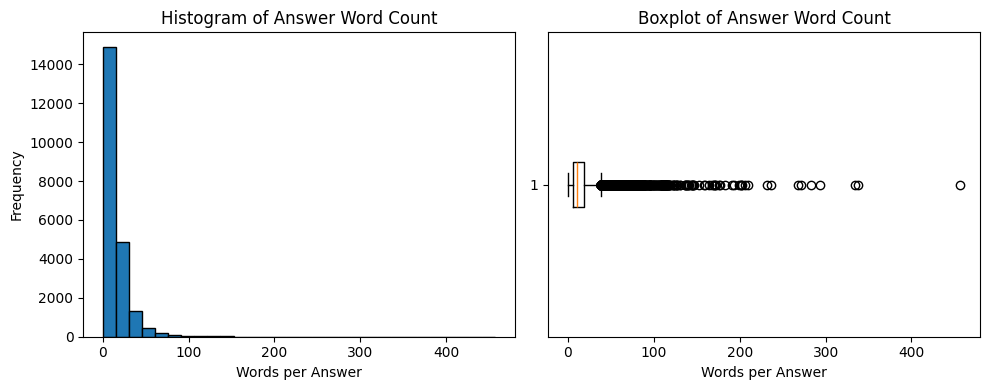

In [52]:
import matplotlib.pyplot as plt

# Plot word count
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df['answer_word_count'], bins=30, edgecolor='black')
plt.title('Histogram of Answer Word Count')
plt.xlabel('Words per Answer')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.boxplot(df['answer_word_count'], vert=False)
plt.title('Boxplot of Answer Word Count')
plt.xlabel('Words per Answer')

plt.tight_layout()
plt.show()

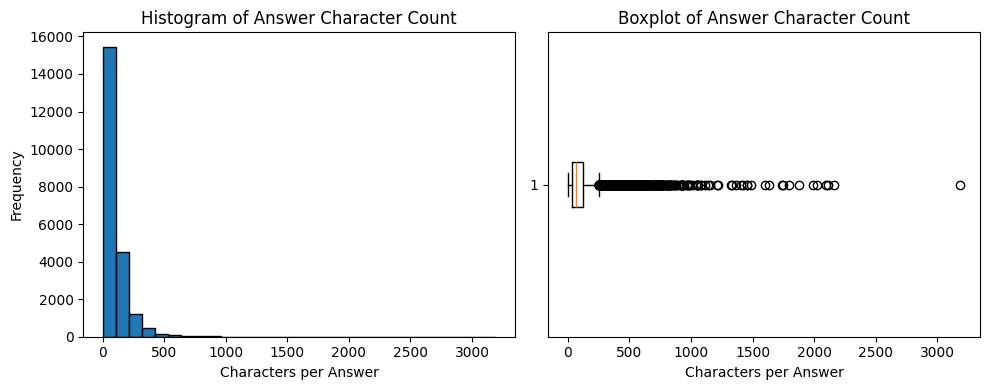

In [53]:
# Plot character count
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df['answer_char_count'], bins=30, edgecolor='black')
plt.title('Histogram of Answer Character Count')
plt.xlabel('Characters per Answer')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.boxplot(df['answer_char_count'], vert=False)
plt.title('Boxplot of Answer Character Count')
plt.xlabel('Characters per Answer')

plt.tight_layout()
plt.show()

####2. Identify the most engaging questions

#####1. Count number of answers per QID

In [54]:
# Count how many times each QID appears = number of answers
qid_answer_counts = df['QID'].value_counts().sort_values(ascending=False)

#####2. Display the most engaging question

In [55]:
# Join back with original questions
question_info = df[['QID', 'QBody']].drop_duplicates().set_index('QID')

# Merge with counts
qid_answer_df = qid_answer_counts.to_frame(name='answer_count').join(question_info)

# Show top 5 most answered questions
print(qid_answer_df.head(5))


         answer_count                                              QBody
QID                                                                     
1556257           315  با ١٥ تومن چه چيزاي از جهاز و ميشه خريد ؟! كه ...
1577970           313  کسی اطلاع داره بخوابم پیش ایشون بريم چطوری و ک...
1559359           215  بعد طلاق چطور خودتونو سرپا نگه داشتین. چطور خو...
1555428           215  من یه سال نامزد کردم قرار یه سال دیگه هم نامزد...
1578477           166  بیاین بگین چیکار میکنین نازتونو میکشه؟. من شوه...


#####3. Summary statistics of engagement

In [56]:
mean_answers = qid_answer_counts.mean()
median_answers = qid_answer_counts.median()
max_answers = qid_answer_counts.max()

print(f"Average answers per question: {mean_answers:.2f}")
print(f"Median answers per question: {median_answers}")
print(f"Max answers for a single question: {max_answers}")

Average answers per question: 22.21
Median answers per question: 15.0
Max answers for a single question: 315


#####4. Visualize distribution of answers per question

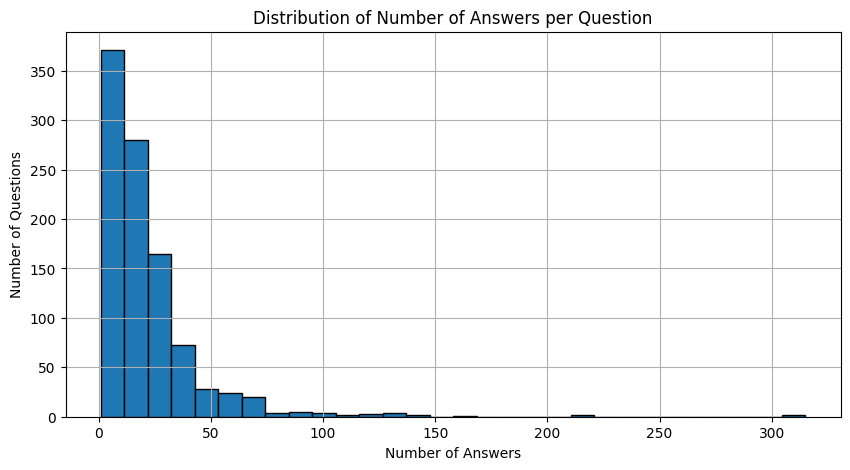

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(qid_answer_counts, bins=30, edgecolor='black')
plt.title('Distribution of Number of Answers per Question')
plt.xlabel('Number of Answers')
plt.ylabel('Number of Questions')
plt.grid(True)
plt.show()

####3. Analyze user activity patterns

#####1. Parse CDate into datetime

In [58]:
# Convert CDate to datetime if not already
df['CDate'] = pd.to_datetime(df['CDate'], errors='coerce')

# Drop any rows with invalid dates
df = df.dropna(subset=['CDate'])

#####2. Extract time features

In [59]:
df['hour'] = df['CDate'].dt.hour
df['weekday'] = df['CDate'].dt.dayofweek  # 0 = Monday, 6 = Sunday
df['weekday_name'] = df['CDate'].dt.day_name()

/tmp/ipython-input-4033077676.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hour'] = df['CDate'].dt.hour
/tmp/ipython-input-4033077676.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['weekday'] = df['CDate'].dt.dayofweek  # 0 = Monday, 6 = Sunday
/tmp/ipython-input-4033077676.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org

#####3. Visualize activity patterns

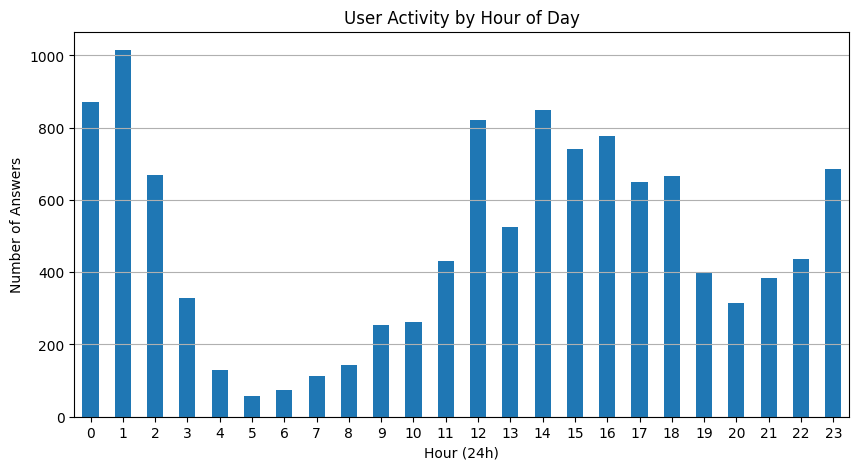

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
df['hour'].value_counts().sort_index().plot(kind='bar')
plt.title("User Activity by Hour of Day")
plt.xlabel("Hour (24h)")
plt.ylabel("Number of Answers")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()


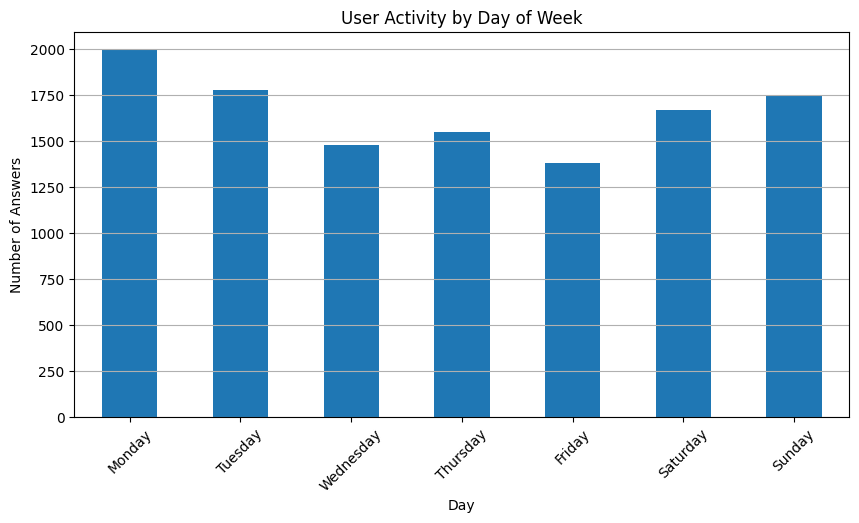

In [61]:
plt.figure(figsize=(10, 5))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['weekday_name'].value_counts().reindex(day_order).plot(kind='bar')
plt.title("User Activity by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Answers")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

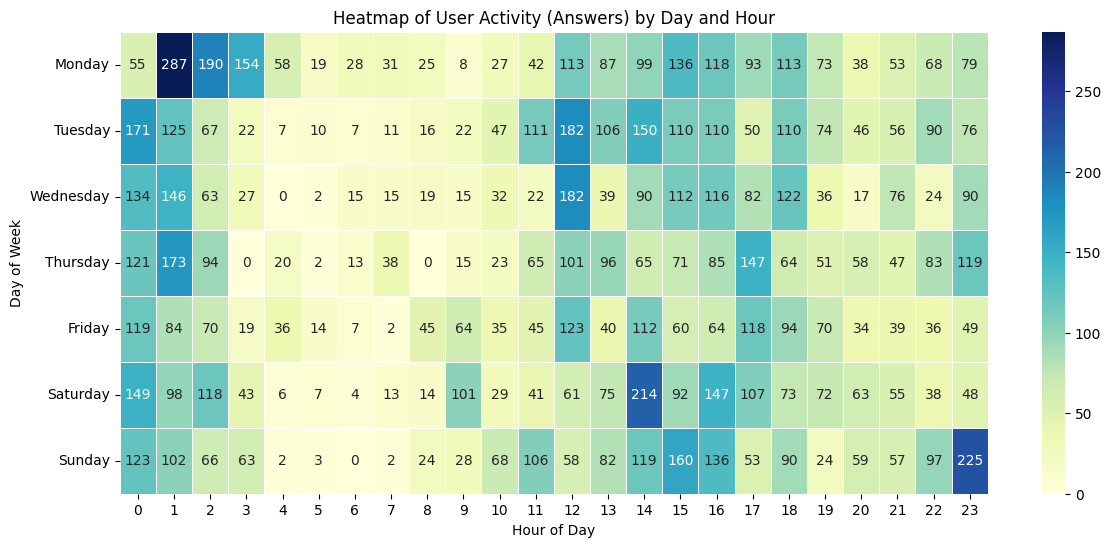

In [62]:
import seaborn as sns
import numpy as np

# Create pivot table: rows = weekday, columns = hour
heatmap_data = df.pivot_table(index='weekday_name', columns='hour', values='QID', aggfunc='count').fillna(0)

# Reorder days
heatmap_data = heatmap_data.reindex(day_order)

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap="YlGnBu", linewidths=.5, annot=True, fmt=".0f")
plt.title("Heatmap of User Activity (Answers) by Day and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.show()

####4. Detect top answer contributors

#####1. Count answers per user

In [63]:
# Count number of answers per user
user_answer_counts = df['CUsername'].value_counts()

#####2. Get top 10 contributors

In [64]:
top_contributors = user_answer_counts.head(10)

#####3. Bar plot of top 10 users

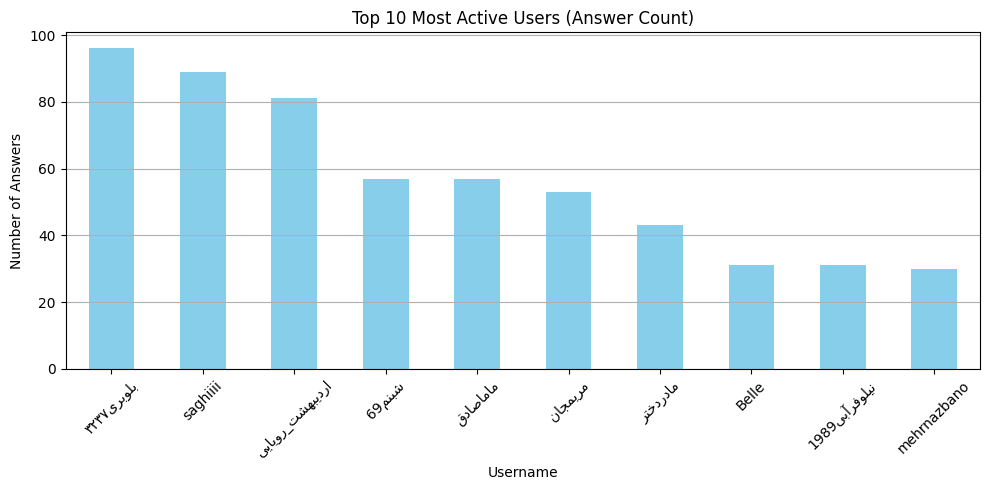

In [65]:
import matplotlib.pyplot as plt
import arabic_reshaper
from bidi.algorithm import get_display

# Reshape Persian usernames
reshaped_labels = [get_display(arabic_reshaper.reshape(label)) for label in top_contributors.index]

# Plot with fixed labels
plt.figure(figsize=(10, 5))
top_contributors.plot(kind='bar', color='skyblue')
plt.title("Top 10 Most Active Users (Answer Count)")
plt.xlabel("Username")
plt.ylabel("Number of Answers")
plt.xticks(ticks=range(len(reshaped_labels)), labels=reshaped_labels, rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

####5. Linguistic and word-level analysis

#####1. Most Frequent Words in Answers

In [66]:
from collections import Counter

# Flatten all tokens from the 'tokens_final' column (answers)
all_answer_words = [word for tokens in df['tokens_final'] for word in tokens]

# Count word frequencies
answer_word_freq = Counter(all_answer_words)

# Display the top 20 most frequent words in answers
top_20_answers = answer_word_freq.most_common(20)

print("🔹 Top 20 most frequent words in ANSWERS:")
for word, freq in top_20_answers:
    print(f"{word}: {freq}")

🔹 Top 20 most frequent words in ANSWERS:
.: 16593
؟: 1692
،: 1551
بچه: 1383
یه: 1353
میشه: 1153
داره: 1022
عزیز: 1018
دکتر: 1010
منم: 976
کن: 922
روز: 917
داشت: 898
الان: 895
دیگه: 874
شیر: 772
دختر: 764
هفته: 754
باشه: 691
بده: 672


#####2. Word Cloud for Answers

In [67]:
# Step 1: Download a Persian-compatible font
!wget -O NotoNaskhArabic-Regular.ttf https://raw.githubusercontent.com/notofonts/noto-fonts/main/hinted/ttf/NotoNaskhArabic/NotoNaskhArabic-Regular.ttf

--2025-08-24 20:36:20--  https://raw.githubusercontent.com/notofonts/noto-fonts/main/hinted/ttf/NotoNaskhArabic/NotoNaskhArabic-Regular.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 178388 (174K) [application/octet-stream]
Saving to: ‘NotoNaskhArabic-Regular.ttf’

NotoNaskhArabic-Reg 100%[===================>] 174.21K  --.-KB/s    in 0.002s  

2025-08-24 20:36:20 (77.7 MB/s) - ‘NotoNaskhArabic-Regular.ttf’ saved [178388/178388]



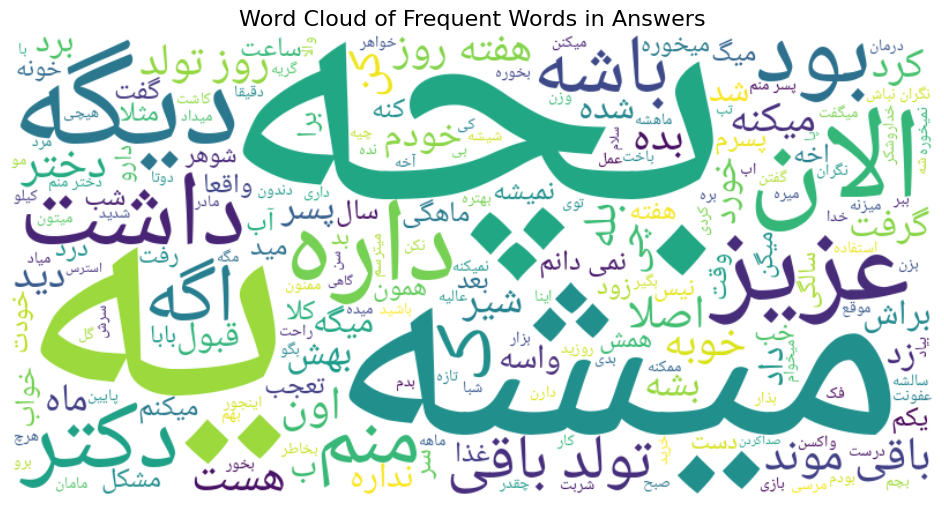

In [68]:
# Step 2: Generate WordCloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Join all tokens in answers
text = " ".join([word for tokens in df['tokens_final'] for word in tokens])

# Generate the word cloud
wordcloud = WordCloud(
    font_path="NotoNaskhArabic-Regular.ttf",  # Use downloaded font
    background_color='white',
    width=800,
    height=400,
    colormap='viridis',
    max_words=200
).generate(text)

# Plot
plt.figure(figsize=(14, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Frequent Words in Answers", fontsize=16)
plt.show()

#####3. Plot unigram, bigram, and trigram frequencies

In [69]:
tokens_cleaned = df['tokens_final'].dropna().tolist()

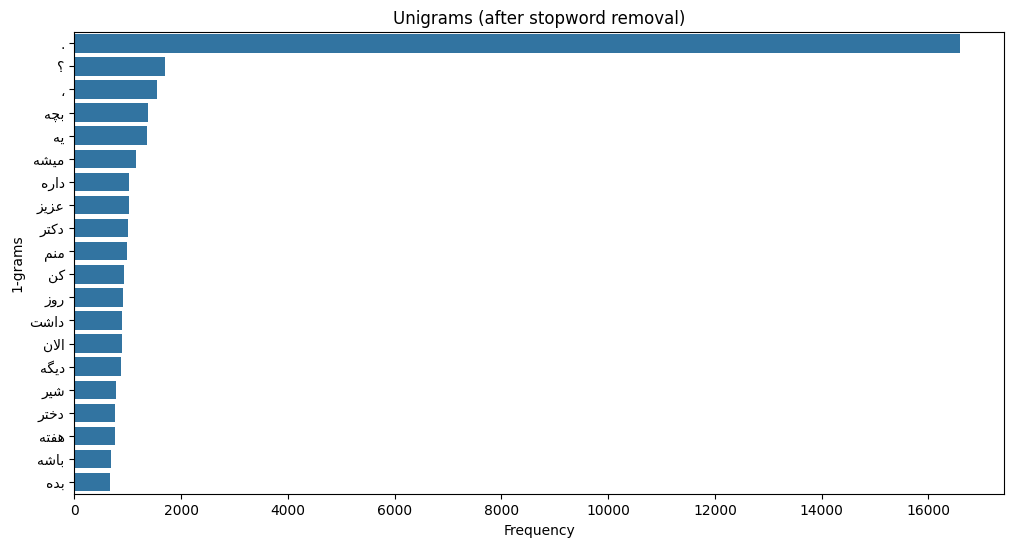

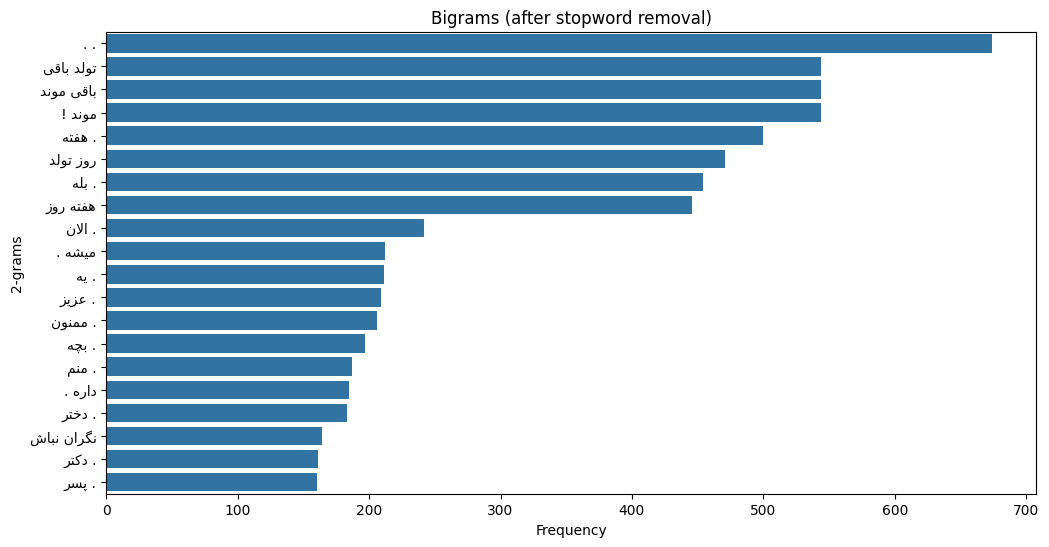

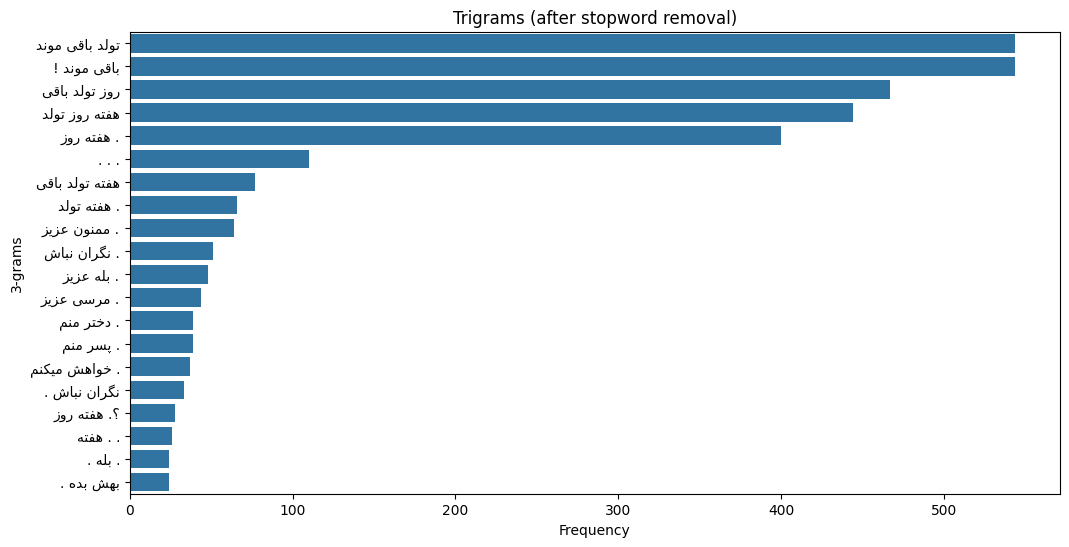

In [70]:
plot_ngrams(tokens_cleaned, n=1, title="Unigrams (after stopword removal)")
plot_ngrams(tokens_cleaned, n=2, title="Bigrams (after stopword removal)")
plot_ngrams(tokens_cleaned, n=3, title="Trigrams (after stopword removal)")

### <font color='skyblue'>3. Analyse the dataset</font>


####1. Load the bge-m3 embedding model

#####1. Load the model

In [71]:
from sentence_transformers import SentenceTransformer

# Load BGE-M3 model
model = SentenceTransformer("BAAI/bge-m3")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/444 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

#####2. Encode a sample question from the dataset

In [72]:
import random

# Pick a random question
sample_qbody = df['QBody'].dropna().sample(1).iloc[0]
print("Sample Question:", sample_qbody)

# Encode using bge-m3
embedding = model.encode(sample_qbody)

print("Embedding shape:", embedding.shape)
print("First 10 values of the vector:\n", embedding[:10])

Sample Question: پسرم دو هفته دیگه دو سالش میشه به معنی واقعی پر حرفه یعنی چشماش که باز میشن شروع میکنه به حرف زدن تا وقتی بخوابه تو ماشین هر چی میبینه بیرون میگه ما هم باید تاییدش کنیم. این ویژگی طبیعیه؟ 
Embedding shape: (1024,)
First 10 values of the vector:
 [-0.01947878  0.00223671  0.01865705  0.00514542 -0.02835622  0.00409112
 -0.01590077  0.01223505 -0.00939862 -0.00866429]


It returns a dense vector, each component is a real number that captures semantic features of the input text in high-dimensional space.

The value (positive or negative) reflects how strongly the sentence expresses that abstract feature.

* A value like 0.12 means the sentence expresses that feature mildly positively

* A value like -0.34 means it negatively correlates with that feature

* A value near 0 means neutral/no correlation

We can usee these embeddings for feed them into downstream ML models.

####2. Install LanceDB and set up an embedding function

#####1. Install the LanceDB Python library

In [73]:
!pip install lancedb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 19.1 MB/s eta 0:00:00


#####2. Define a custom embedding function

In [74]:
!pip install sentence-transformers -q

In [75]:
import numpy as np
from sentence_transformers import SentenceTransformer
from lancedb.embeddings.base import TextEmbeddingFunction
from lancedb.embeddings import get_registry, register
from typing import List

@register("bge-m3-local")
class BgeM3EmbeddingFunction(TextEmbeddingFunction):
    name: str = "BAAI/bge-m3"
    device: str = "cpu"

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self._model = SentenceTransformer(self.name, device=self.device)

    def ndims(self) -> int:
        return self._model.get_sentence_embedding_dimension()

    def generate_embeddings(self, texts: list[str]) -> list[list[float]]:
        embeddings = self._model.encode(texts, normalize_embeddings=True)
        return [arr.tolist() for arr in embeddings]

####3. Define a schema for the vector database

In [76]:
import lancedb
from lancedb.pydantic import pydantic_to_schema, Vector
from pydantic import BaseModel

# 1. Define the schema as a Pydantic model
class NiniSiteSchema(BaseModel):
    # Field for the unique question ID
    qid: int

    # Field for the raw (original) question text
    qbody: str

    # Define the vector field using the 'Vector' type from LanceDB.
    # We must specify the dimension of our bge-m3 embeddings, which is 1024.
    embedding: Vector(1024)

# 2. (Optional but good practice) You can view the schema LanceDB creates
print(pydantic_to_schema(NiniSiteSchema))

qid: int64 not null
qbody: string not null
embedding: fixed_size_list<item: float>[1024]
  child 0, item: float


####4. Create and populate a LanceDB table

#####1. Use defined schema to create a new table.

In [77]:
import lancedb
import pandas as pd
import json
from lancedb.embeddings import EmbeddingFunctionConfig

# --- Set up the LanceDB Table (Updated) ---
# Connect to the database
db = lancedb.connect("nini_site.lance")

# Instantiate custom embedding function
embedding_function = get_registry().get("bge-m3-local").create()

schema = pydantic_to_schema(NiniSiteSchema)

#####2. Load the Nini Site dataset (questions only, excluding comments) into this table

In [78]:
# Load the raw JSON file
with open('/content/drive/MyDrive/DataScience/CAs/CA56/Task2/PerCQA_JSON_Format.json', 'r', encoding='utf-8-sig') as f:
    raw_data = json.load(f)

# Extract only the question data, ensuring no duplicates.
# We create a list of dictionaries, each containing the QID and QBody.
questions_data = [
    {
        "qid": item["QID"],
        "qbody": item["QBody"]
    }
    for item in raw_data
]

In [79]:
# Convert the list of questions into a pandas DataFrame
questions_df = pd.DataFrame(questions_data)

In [80]:
questions_df.drop_duplicates(subset=['qid'], inplace=True)

print(f"Number of unique questions after de-duplication: {len(questions_df)}")

Number of unique questions after de-duplication: 990


In [81]:
# Create the table, passing the embedding function directly.
# The `EmbeddingFunctionConfig` tells LanceDB which function to use for which column.
tbl = db.create_table(
    "nini_site_questions",
    schema=schema,
    mode="overwrite",
    embedding_functions=[
        EmbeddingFunctionConfig(
            vector_column="embedding",
            source_column="qbody",
            function=embedding_function
        )
    ]
)


In [82]:
# Add the DataFrame to the table.
# LanceDB will now automatically process each 'qbody', generate the embedding,
# and store the complete record (qid, qbody, embedding).
tbl.add(questions_df)

AddResult(version=2)

In [83]:
print(f"Successfully created and populated the table.")
print(f"Number of rows in the table: {len(tbl)}")
print("\nTable Schema:")
print(tbl.schema)
print("\nFirst 5 rows of the table:")
print(tbl.to_pandas().head())

Successfully created and populated the table.
Number of rows in the table: 990

Table Schema:
qid: int64 not null
qbody: string not null
embedding: fixed_size_list<item: float>[1024]
  child 0, item: float
-- schema metadata --
embedding_functions: '[
  {
    "name": "bge-m3-local",
    "model": {},
' + 68

First 5 rows of the table:
       qid                                              qbody  \
0  1550088  دوستان نامزدم (شوهرم)باهام قهره امروز تولدشه چ...   
1  1558609  من خودم حس میکنم اشتباهم گیر دادن بیخودی و غر ...   
2  1587820  سالگرد ازدواجم نزدیکه چی بخرم. سالگرد دوممونه....   
3  4414921  دختر من چهارده ماهه است. آیا برای تشخیص پرانتز...   
4  3109668   چه پمادی بزنم و از چیه اینجور شده  . واضح نیس...   

                                           embedding  
0  [0.043938152, 0.03664006, -0.010585843, -0.010...  
1  [-0.03775334, -0.0014564429, -0.030918509, -0....  
2  [-0.029951325, 0.067306384, -0.038232263, 0.03...  
3  [-0.031048281, 0.018678509, -0.044434678, 0.01... 

####5. Perform semantic search with LanceDB

#####1. Use LanceDB’s search function to retrieve the top 5 semantically similar results

In [84]:
# --- 1. Define Your Search Queries ---
queries = [
    "چرا نوزاد من مدام گریه می کند؟",
    "بهترین غذا برای کودک یک ساله چیست؟",
    "علائم اولیه بارداری کدامند؟",
    "راه های افزایش شیر مادر چیست؟",
    "چطور میتوانم به فرزندم خواندن یاد بدهم؟"
]

In [85]:
# --- 2. Perform the Search and Display Results ---
for query in queries:
    print(f"=================================================")
    print(f"▶️  QUERY: '{query}'")
    print(f"=================================================\n")

    # Use the search function on the table
    # It automatically uses the bge-m3 function to embed the query
    results_df = tbl.search(query).limit(5).to_pandas()

    print("🔎 Top 5 Semantically Similar Results:\n")
    # Iterate through the results and print them
    for index, row in results_df.iterrows():
        # The '_distance' column shows how close the vectors are (lower is better)
        print(f"  ➡️  Score: {1 - row['_distance']:.4f} | QID: {row['qid']}")
        print(f"      Question: {row['qbody']}\n")


▶️  QUERY: 'چرا نوزاد من مدام گریه می کند؟'

🔎 Top 5 Semantically Similar Results:

  ➡️  Score: 0.4319 | QID: 4185058
      Question: بچم یک سال و ۲ ماهشه. دائما تو خواب گریه میکنه شدید همش هق هق میکنه . یک وقتهایی که اصلا جیغ میزنه و بیدار میشه . نکنه بچم اعصابش ضعیفه کسی میدونه علتش چیه ؟ خیلی هم وابسته به شوهرمه اونم یه وقتایی خسته میشه بغلش نمیکنه این طفلی هم گریه میکنه که بغلم کن . میگم نکنه برا اونه . البته توی دندونه درآوردنه نکنه مال اونه؟ 

  ➡️  Score: 0.3281 | QID: 3182719
      Question: دخترم ۱۳ ماهشه تقریبا چند وقتی هست که تو خواب بعضی وقتها ناله و گریه می‌کنه . خیلییی نگرانم. کسی تجربه ای داره؟ البته خیلی نیست شبی چند دقیقه هست

  ➡️  Score: 0.3265 | QID: 3323950
      Question:  دخترم شبها‌ نمیخوابه همش هر یک ربع یا یک ساعت  گریه میکنه یا شیر میخوره یا میندازمش رو پاهام.  کسی تجربه داره دکترم بردمش نتیجه نگرفتم دارو گیاهی داد ولی تاثیر نداشت. 

  ➡️  Score: 0.3192 | QID: 3285871
      Question: دخترم ۱۶ماهشه از اول ک دنیا اومد خوابش خیلی خوب بود الان ۱ماهه ک شبا تو خوا

#####2. Evaluate whether the results are semantically relevant to the query Manually

As we see, all the result are semantically relevant to the wueries

####6. Implement classical full-text search using LanceDB

#####1. Create a full-text index on qbody

In [86]:
# Create a full-text search index on the 'qbody' column
tbl.create_fts_index("qbody")

print("Successfully created a full-text search index on 'qbody'.")

Successfully created a full-text search index on 'qbody'.


In [87]:
# --- 1. Define the Same Search Queries ---
queries = [
    "چرا نوزاد من مدام گریه می کند؟",
    "بهترین غذا برای کودک یک ساله چیست؟",
    "علائم اولیه بارداری کدامند؟",
    "راه های افزایش شیر مادر چیست؟",
    "چطور میتوانم به فرزندم خواندن یاد بدهم؟"
]

# --- 2. Perform the FTS and Display Results (Corrected) ---
for query in queries:
    print(f"=================================================")
    print(f"▶️  FTS QUERY: '{query}'")
    print(f"=================================================\n")

    # The search function still works correctly
    results_df = tbl.search(query).limit(5).to_pandas()

    print("🔎 Top 5 Full-Text Search Results:\n")
    for index, row in results_df.iterrows():
        print(f"  ➡️  QID: {row['qid']}")
        print(f"      Question: {row['qbody']}\n")

▶️  FTS QUERY: 'چرا نوزاد من مدام گریه می کند؟'

🔎 Top 5 Full-Text Search Results:

  ➡️  QID: 4185058
      Question: بچم یک سال و ۲ ماهشه. دائما تو خواب گریه میکنه شدید همش هق هق میکنه . یک وقتهایی که اصلا جیغ میزنه و بیدار میشه . نکنه بچم اعصابش ضعیفه کسی میدونه علتش چیه ؟ خیلی هم وابسته به شوهرمه اونم یه وقتایی خسته میشه بغلش نمیکنه این طفلی هم گریه میکنه که بغلم کن . میگم نکنه برا اونه . البته توی دندونه درآوردنه نکنه مال اونه؟ 

  ➡️  QID: 3182719
      Question: دخترم ۱۳ ماهشه تقریبا چند وقتی هست که تو خواب بعضی وقتها ناله و گریه می‌کنه . خیلییی نگرانم. کسی تجربه ای داره؟ البته خیلی نیست شبی چند دقیقه هست

  ➡️  QID: 3323950
      Question:  دخترم شبها‌ نمیخوابه همش هر یک ربع یا یک ساعت  گریه میکنه یا شیر میخوره یا میندازمش رو پاهام.  کسی تجربه داره دکترم بردمش نتیجه نگرفتم دارو گیاهی داد ولی تاثیر نداشت. 

  ➡️  QID: 3285871
      Question: دخترم ۱۶ماهشه از اول ک دنیا اومد خوابش خیلی خوب بود الان ۱ماهه ک شبا تو خواب هر نیم ساعت گریه میکنه یا نق میزنه خوابه ها با چشم بسته خیلی د

#####2. Compare the results with those from semantic search

For this specific task, semantic search gives significantly more relevant and useful results.

* Full-Text Search (FTS) is rigid. It's very good at finding exact phrases or names, but it fails to understand the user's intent. It cannot grasp synonyms, related concepts, or context. If a user phrases their question slightly differently from how it's stored in the database, FTS might fail to find a perfect match.

* Semantic Search is flexible and intelligent. By understanding the meaning behind the words, it provides a much more human-like search experience. It finds conceptually related content, which is exactly what a user on a Q&A forum like NiniSite needs. They are looking for answers to their problem, regardless of how the question was originally worded.

For my specific query, the result was same.

####7. Research hybrid search techniques

What is Hybrid Search?

Hybrid search is a sophisticated search technique that combines the results of keyword-based (full-text) search and vector-based (semantic) search. Instead of relying on just one method, it runs both searches in parallel and then intelligently merges the results to provide a single, more accurate, and comprehensive list of answers.

Why is Hybrid Search More Effective?
Hybrid search is often more effective than using a single method because it balances the weaknesses of one with the strengths of the other, leading to superior relevance and recall.

1. Precision of Keywords, Breadth of Semantics:

* Problem: Semantic search might sometimes miss results containing specific, important keywords (like a product model number or a unique jargon term) if the overall context doesn't align perfectly. Full-text search, on the other hand, can miss conceptually similar results that use different words.

* Hybrid Solution: It ensures that documents with exact keyword matches are always included, while also capturing the broader, semantically related results. This guarantees that you don't miss obvious matches while still benefiting from the "intelligence" of vector search.

2. Handles "Out-of-Vocabulary" Queries Better:

* Problem: Vector models are trained on vast but finite datasets. If a query contains a very new, rare, or domain-specific term (e.g., a new technical acronym), the semantic model might not have a good vector representation for it and could return poor results.

* Hybrid Solution: The keyword-based search will still find exact matches for that rare term, acting as a crucial safety net where the semantic model falls short.

3. Improved Relevance Ranking (Reciprocal Rank Fusion):

* Problem: How do you decide which results are truly the best? Semantic search ranks by vector distance, and full-text search ranks by keyword frequency (like TF-IDF or BM25). Which is more important?

* Hybrid Solution: Advanced hybrid systems use sophisticated algorithms like Reciprocal Rank Fusion (RRF) to merge the two ranked lists. RRF looks at the rank (1st, 2nd, 3rd, etc.) of each result in both lists, not just its raw score. It gives higher priority to documents that appear high up in both search results, effectively letting the two methods "vote" on which documents are most relevant. This often produces a final ranking that is better than either individual list.

####8. Evaluation methods

**Precision@k (Precision at k)**
* What it is: This is the most straightforward metric. It answers the question: "Out of the top k results shown to the user, how many were actually relevant?"

* How it works: You look only at the first k results (e.g., the top 5 or top 10). You count how many of them are relevant (which requires a human judgment or a pre-labeled dataset) and divide by k.

* Example: If you search for "baby food" and 4 out of the top 5 results are relevant, your Precision@5 is 4/5 or 80%.

* Use Case: It's perfect for evaluating systems like web search where users rarely look beyond the first few results.

**Recall**
* What it is: Recall answers a different question: "Out of all the possible relevant documents in the entire database, how many did my search system find?"

* How it works: You need to know the total number of relevant documents in the whole collection. You then count how many of those your search returned (anywhere in the results, not just the top k) and divide by the total number of relevant documents.

* Example: If there are 100 total documents about "early pregnancy signs" in the database and your search finds 70 of them, your recall is 70/100 or 70%.

* Use Case: Recall is critical in situations where you cannot afford to miss anything, such as in legal discovery (finding all relevant documents for a case) or medical diagnoses.

**NDCG (Normalized Discounted Cumulative Gain)**
* What it is: NDCG is a more advanced metric that evaluates the quality of the ranking, not just the relevance. It operates on two principles:

1. Highly relevant documents are more valuable than somewhat relevant documents.

2. Relevant documents that appear earlier in the results are more valuable than those that appear later.

* How it works: It assigns a relevance score to each result (e.g., 0=irrelevant, 1=somewhat relevant, 2=highly relevant). It then calculates a "gain" for the entire list, giving higher scores to relevant items at the top and "discounting" (reducing the value of) items that appear further down. This score is then normalized (scaled from 0 to 1) by comparing it to the score of a "perfect" ranking.

* Use Case: NDCG is the gold standard for evaluating modern search and recommendation systems where the order and quality of results are paramount.

### <font color='skyblue'>4. Answer Ranking Enhancement with a Reranker</font>


####1. Install and Load the Reranker Model

In [88]:
!pip install sentence-transformers -q

In [91]:
from sentence_transformers.cross_encoder import CrossEncoder

# Load the reranker model from Hugging Face
reranker = CrossEncoder('BAAI/bge-reranker-base')

config.json:   0%|          | 0.00/799 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/279 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

####2. Search and Rerank


In [89]:
# --- 1. Define Your Search Queries ---
queries = [
    "چرا نوزاد من مدام گریه می کند؟",
    "بهترین غذا برای کودک یک ساله چیست؟",
    "علائم اولیه بارداری کدامند؟",
    "راه های افزایش شیر مادر چیست؟",
    "چطور میتوانم به فرزندم خواندن یاد بدهم؟"
]

In [92]:
# --- 2. Perform Search, Rerank, and Display Results ---
for query in queries:
    print(f"===========================================================")
    print(f"▶️  QUERY: '{query}'")
    print(f"===========================================================\n")

    # --- Step 1: Initial Retrieval (Semantic Search) ---
    # Retrieve a larger set of candidates, e.g., the top 25
    initial_results_df = tbl.search(query).limit(25).to_pandas()

    print("--- 🥇 Initial Top 5 Results (Before Reranking) ---\n")
    for index, row in initial_results_df.head(5).iterrows():
        print(f"  ➡️  QID: {row['qid']}")
        print(f"      Question: {row['qbody']}\n")

    # --- Step 2: Reranking with Cross-Encoder ---
    # Create pairs of [query, document] for the reranker
    pairs = [[query, doc] for doc in initial_results_df['qbody']]

    # Get the new scores from the reranker model
    rerank_scores = reranker.predict(pairs)

    # Add the new scores to our DataFrame
    initial_results_df['rerank_score'] = rerank_scores

    # Sort the DataFrame by the new rerank_score in descending order
    reranked_df = initial_results_df.sort_values(by='rerank_score', ascending=False)

    print("--- 🏆 Final Top 5 Results (After Reranking) ---\n")
    for index, row in reranked_df.head(5).iterrows():
        print(f"  ➡️  New Score: {row['rerank_score']:.4f} | QID: {row['qid']}")
        print(f"      Question: {row['qbody']}\n")

▶️  QUERY: 'چرا نوزاد من مدام گریه می کند؟'

--- 🥇 Initial Top 5 Results (Before Reranking) ---

  ➡️  QID: 4185058
      Question: بچم یک سال و ۲ ماهشه. دائما تو خواب گریه میکنه شدید همش هق هق میکنه . یک وقتهایی که اصلا جیغ میزنه و بیدار میشه . نکنه بچم اعصابش ضعیفه کسی میدونه علتش چیه ؟ خیلی هم وابسته به شوهرمه اونم یه وقتایی خسته میشه بغلش نمیکنه این طفلی هم گریه میکنه که بغلم کن . میگم نکنه برا اونه . البته توی دندونه درآوردنه نکنه مال اونه؟ 

  ➡️  QID: 3182719
      Question: دخترم ۱۳ ماهشه تقریبا چند وقتی هست که تو خواب بعضی وقتها ناله و گریه می‌کنه . خیلییی نگرانم. کسی تجربه ای داره؟ البته خیلی نیست شبی چند دقیقه هست

  ➡️  QID: 3323950
      Question:  دخترم شبها‌ نمیخوابه همش هر یک ربع یا یک ساعت  گریه میکنه یا شیر میخوره یا میندازمش رو پاهام.  کسی تجربه داره دکترم بردمش نتیجه نگرفتم دارو گیاهی داد ولی تاثیر نداشت. 

  ➡️  QID: 3285871
      Question: دخترم ۱۶ماهشه از اول ک دنیا اومد خوابش خیلی خوب بود الان ۱ماهه ک شبا تو خواب هر نیم ساعت گریه میکنه یا نق میزنه خوابه ها با چش

####3. Compare and report the difference in results before and after reranking

The key difference is that the reranked results are often more direct and explicit answers to the user's query. The reranker excels at promoting documents that don't just share a topic, but truly address the specific intent of the question, leading to a noticeably more relevant and satisfying user experience.